# 🎓 Stage 1: Student Performance Analyzer
### ML Roadmap — Python & Data Wrangling Project

## Step 0: Install & Import Libraries

These are the core libraries every data scientist uses daily.

In [ ]:
# Uncomment the line below if running for the first time
# !pip install pandas numpy matplotlib seaborn

import pandas as pd          # Data manipulation — the backbone of data science
import numpy as np           # Numerical computing
import matplotlib.pyplot as plt  # Base plotting library
import seaborn as sns        # High-level statistical visualisation
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)   
pd.set_option('display.float_format', '{:.2f}'.format)  
plt.style.use('seaborn-v0_8-whitegrid')  

---
## Step 1: Generate the Dataset


In [ ]:
import os

def generate_student_dataset(n=500, seed=42):
    """
    Generate a realistic Tamil Nadu student performance dataset.
    
    Parameters:
        n    : Number of student records
        seed : Random seed for reproducibility
    
    Returns:
        pd.DataFrame with intentional missing values
    """
    np.random.seed(seed)

    # --- Name pools (Tamil names) ---
    male_names   = ['Arjun','Karthik','Vijay','Ravi','Suresh','Mohan','Ganesh',
                    'Siva','Bala','Dinesh','Mani','Arun','Kumar','Naveen','Pradeep']
    female_names = ['Priya','Deepa','Kavya','Anjali','Meena','Lakshmi','Pooja',
                    'Nithya','Saranya','Divya','Ananya','Revathi','Bhavani','Keerthana','Sneha']
    last_names   = ['Kumar','Rajan','Selvam','Murugan','Krishnan','Subramanian',
                    'Pandian','Ramesh','Narayanan','Devi','Pillai','Shankar','Raj','Nair','Velu']

    departments    = ['Computer Science','Electronics','Mechanical','Civil','Information Technology']
    regions        = ['Chennai','Coimbatore','Madurai','Trichy','Salem','Erode','Vellore','Tirunelveli']
    parent_edus    = ['No Schooling','School','Diploma','Graduate','Post-Graduate']
    parent_weights = [0.05, 0.20, 0.25, 0.35, 0.15]

    genders     = np.random.choice(['Male', 'Female'], n)
    first_names = [
        np.random.choice(male_names) if g == 'Male' else np.random.choice(female_names)
        for g in genders
    ]

    df = pd.DataFrame({
        'student_id'           : [f'STU{1000+i}' for i in range(n)],
        'name'                 : [f'{fn} {np.random.choice(last_names)}' for fn in first_names],
        'gender'               : genders,
        'age'                  : np.random.randint(18, 23, n),
        'department'           : np.random.choice(departments, n),
        'region'               : np.random.choice(regions, n),
        'attendance_pct'       : np.clip(np.random.normal(78, 12, n), 40, 100).round(1),
        'study_hours_per_day'  : np.clip(np.random.normal(4.5, 1.5, n), 1, 10).round(1),
        'math_score'           : np.clip(np.random.normal(68, 15, n), 20, 100).round(0).astype(int),
        'science_score'        : np.clip(np.random.normal(65, 14, n), 20, 100).round(0).astype(int),
        'english_score'        : np.clip(np.random.normal(70, 12, n), 25, 100).round(0).astype(int),
        'programming_score'    : np.clip(np.random.normal(63, 18, n), 15, 100).round(0).astype(int),
        'tamil_score'          : np.clip(np.random.normal(72, 11, n), 30, 100).round(0).astype(int),
        'part_time_job'        : np.random.choice(['Yes', 'No'], n, p=[0.25, 0.75]),
        'internet_access'      : np.random.choice(['Yes', 'No'], n, p=[0.85, 0.15]),
        'parent_education'     : np.random.choice(parent_edus, n, p=parent_weights),
        'family_income_lpa'    : np.clip(np.random.exponential(4.5, n), 1, 25).round(1),
    })

    # --- Introduce realistic missing values (4% per column) ---
    missing_cols = ['math_score', 'science_score', 'attendance_pct', 'family_income_lpa']
    for col in missing_cols:
        idx = np.random.choice(df.index, size=int(n * 0.04), replace=False)
        df.loc[idx, col] = np.nan

    return df


# Generate the dataset
df_raw = generate_student_dataset(n=500)

# Save raw version to disk
df_raw.to_csv('student_performance.csv', index=False)

print(f'✅ Dataset generated: {df_raw.shape[0]} students × {df_raw.shape[1]} features')
print(f'   Saved to: student_performance.csv')
df_raw.head()

✅ Dataset generated: 500 students × 17 features
   Saved to: student_performance.csv


,student_id,name,gender,age,department,region,attendance_pct,study_hours_per_day,math_score,science_score,english_score,programming_score,tamil_score,part_time_job,internet_access,parent_education,family_income_lpa
0,STU1000,Pradeep Krishnan,Male,20,Civil,Tirunelveli,78.40,4.00,47.00,53.00,69,70,73,No,Yes,Graduate,1.50
1,STU1001,Bhavani Devi,Female,20,Electronics,Madurai,67.80,7.50,62.00,47.00,53,83,92,No,Yes,Graduate,1.60
2,STU1002,Suresh Velu,Male,21,Information Technology,Trichy,80.10,4.50,92.00,77.00,83,45,90,Yes,Yes,Post-Graduate,2.30
3,STU1003,Ganesh Narayanan,Male,21,Mechanical,Trichy,80.90,5.50,93.00,64.00,100,53,86,Yes,No,Post-Graduate,8.60
4,STU1004,Arjun Subramanian,Male,19,Computer Science,Vellore,67.70,4.80,46.00,47.00,64,100,100,No,No,Post-Graduate,3.10


---
## Step 2: First Look at the Data


In [ ]:
# --- Basic shape & structure ---
print('=' * 55)
print(f'  Rows    : {df_raw.shape[0]}')
print(f'  Columns : {df_raw.shape[1]}')
print('=' * 55)

print('\nColumn data types:')
print(df_raw.dtypes)

print('\n Basic statistics (numeric columns):')
df_raw.describe().round(2)

  Rows    : 500
  Columns : 17

Column data types:
student_id                 str
name                       str
gender                     str
age                      int32
department                 str
region                     str
attendance_pct         float64
study_hours_per_day    float64
math_score             float64
science_score          float64
english_score            int64
programming_score        int64
tamil_score              int64
part_time_job              str
internet_access            str
parent_education           str
family_income_lpa      float64
dtype: object

 Basic statistics (numeric columns):


,age,attendance_pct,study_hours_per_day,math_score,science_score,english_score,programming_score,tamil_score,family_income_lpa
count,500.00,480.00,500.00,480.00,480.00,500.00,500.00,500.00,480.00
mean,19.95,78.11,4.65,68.70,63.90,70.83,62.71,71.19,4.66
std,1.43,11.74,1.51,15.29,13.59,12.00,16.94,10.66,4.50
min,18.00,44.30,1.00,24.00,20.00,38.00,16.00,31.00,1.00
25%,19.00,70.20,3.70,59.00,55.00,63.00,51.00,64.00,1.30
50%,20.00,77.90,4.70,69.00,64.00,70.00,63.00,72.00,3.00
75%,21.00,87.12,5.60,79.00,72.00,79.00,74.00,78.00,6.32
max,22.00,100.00,9.40,100.00,100.00,100.00,100.00,100.00,25.00


In [6]:
# --- Missing value audit ---
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count'  : missing,
    'Missing %'      : missing_pct,
    'Data Type'      : df_raw.dtypes
}).query('`Missing Count` > 0')

# print(missing)
print('🔍 Missing Value Report:')
print(missing_report.to_string())
print(f'\n   Total cells : {df_raw.size:,}')
print(f'   Missing cells: {df_raw.isnull().sum().sum():,}')

🔍 Missing Value Report:
                   Missing Count  Missing % Data Type
attendance_pct                20       4.00   float64
math_score                    20       4.00   float64
science_score                 20       4.00   float64
family_income_lpa             20       4.00   float64

   Total cells : 8,500
   Missing cells: 80


In [7]:
# --- Check for duplicate rows ---
dup_count = df_raw.duplicated().sum()
print(f'🔁 Duplicate rows: {dup_count}')

# --- Value counts for categorical columns ---
cat_cols = ['gender', 'department', 'region', 'part_time_job', 'internet_access', 'parent_education']
for col in cat_cols:
    print(f'\n📌 {col}:')
    print(df_raw[col].value_counts().to_string())

🔁 Duplicate rows: 0

📌 gender:
gender
Female    256
Male      244

📌 department:
department
Civil                     112
Electronics               106
Information Technology     99
Computer Science           98
Mechanical                 85

📌 region:
region
Trichy         72
Salem          72
Coimbatore     64
Erode          63
Tirunelveli    59
Chennai        59
Vellore        57
Madurai        54

📌 part_time_job:
part_time_job
No     389
Yes    111

📌 internet_access:
internet_access
Yes    421
No      79

📌 parent_education:
parent_education
Graduate         199
Diploma          109
School            91
Post-Graduate     78
No Schooling      23



## Step 3: Data Cleaning


In [8]:
# Work on a copy — NEVER modify raw data directly
df = df_raw.copy()

# ── 3.1 Fill missing numeric values with column median ──────────────────────
numeric_missing = ['math_score', 'science_score', 'attendance_pct', 'family_income_lpa']

for col in numeric_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f' {col:<25} → filled {df_raw[col].isnull().sum()} NaNs with median = {median_val:.2f}')

# ── 3.2 Verify no missing values remain ─────────────────────────────────────
remaining_nulls = df.isnull().sum().sum()
print(f'\n   Remaining missing values: {remaining_nulls} ' if remaining_nulls == 0 else f'   Still {remaining_nulls} missing!')

 math_score                → filled 20 NaNs with median = 69.00
 science_score             → filled 20 NaNs with median = 64.00
 attendance_pct            → filled 20 NaNs with median = 77.90
 family_income_lpa         → filled 20 NaNs with median = 3.00

   Remaining missing values: 0 


In [9]:
# ── 3.3 Fix data types ───────────────────────────────────────────────────────
# Scores should be integers after filling
for col in ['math_score', 'science_score']:
    df[col] = df[col].astype(int)

# Convert boolean-like columns to proper category type
cat_cols = ['gender', 'department', 'region', 'part_time_job', 'internet_access', 'parent_education']
for col in cat_cols:
    df[col] = df[col].astype('category')

print('Data types after cleaning:')
print(df.dtypes)

# ── 3.4 Validate score ranges (20–100 is our valid range) ───────────────────
score_cols = ['math_score', 'science_score', 'english_score', 'programming_score', 'tamil_score']
print('\n📏 Score range validation:')
for col in score_cols:
    lo, hi = df[col].min(), df[col].max()
    status = '✅' if lo >= 0 and hi <= 100 else '⚠️ OUT OF RANGE'
    print(f'   {col:<22} min={lo:3d}  max={hi:3d}  {status}')

Data types after cleaning:
student_id                  str
name                        str
gender                 category
age                       int32
department             category
region                 category
attendance_pct          float64
study_hours_per_day     float64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
tamil_score               int64
part_time_job          category
internet_access        category
parent_education       category
family_income_lpa       float64
dtype: object

📏 Score range validation:
   math_score             min= 24  max=100  ✅
   science_score          min= 20  max=100  ✅
   english_score          min= 38  max=100  ✅
   programming_score      min= 16  max=100  ✅
   tamil_score            min= 31  max=100  ✅



## Step 4: Feature Engineering

In [10]:
score_cols = ['math_score', 'science_score', 'english_score', 'programming_score', 'tamil_score']

# ── 4.1 Total and Average score ──────────────────────────────────────────────
df['total_score']   = df[score_cols].sum(axis=1)
df['average_score'] = df[score_cols].mean(axis=1).round(2)

# ── 4.2 Grade (standard letter grade system) ─────────────────────────────────
def assign_grade(avg):
    if avg >= 85: return 'A'
    elif avg >= 70: return 'B'
    elif avg >= 55: return 'C'
    elif avg >= 40: return 'D'
    else: return 'F'

df['grade'] = df['average_score'].apply(assign_grade)

# ── 4.3 Pass / Fail (fail if any subject < 40) ───────────────────────────────
df['result'] = df[score_cols].apply(
    lambda row: 'Pass' if (row >= 40).all() else 'Fail', axis=1
)

# ── 4.4 Performance tier (top 25% / bottom 25% / average) ────────────────────
q75 = df['average_score'].quantile(0.75)
q25 = df['average_score'].quantile(0.25)

def performance_tier(avg):
    if avg >= q75: return 'Top'
    elif avg <= q25: return 'Weak'
    else: return 'Average'

df['performance_tier'] = df['average_score'].apply(performance_tier)

# ── 4.5 Study efficiency = average score per study hour ──────────────────────
df['study_efficiency'] = (df['average_score'] / df['study_hours_per_day']).round(2)

# ── 4.6 Attendance category ──────────────────────────────────────────────────
df['attendance_category'] = pd.cut(
    df['attendance_pct'],
    bins=[0, 60, 75, 85, 100],
    labels=['Poor (<60%)', 'Average (60–75%)', 'Good (75–85%)', 'Excellent (>85%)']
)

print('✅ New features created:')
new_cols = ['total_score','average_score','grade','result','performance_tier','study_efficiency','attendance_category']
for col in new_cols:
    print(f'   {col}')

df[['name','average_score','grade','result','performance_tier','study_efficiency']].head(8)

✅ New features created:
   total_score
   average_score
   grade
   result
   performance_tier
   study_efficiency
   attendance_category


,name,average_score,grade,result,performance_tier,study_efficiency
0,Pradeep Krishnan,62.40,C,Pass,Weak,15.60
1,Bhavani Devi,67.40,C,Pass,Average,8.99
2,Suresh Velu,77.40,B,Pass,Top,17.20
3,Ganesh Narayanan,79.20,B,Pass,Top,14.40
4,Arjun Subramanian,71.40,B,Pass,Average,14.88
5,Kavya Pillai,72.60,B,Pass,Top,18.15
6,Karthik Pillai,62.80,C,Fail,Weak,39.25
7,Bala Kumar,71.40,B,Pass,Average,16.23


## Step 5: Descriptive Statistics & Analysis



In [11]:
print('='*60)
print('            STUDENT PERFORMANCE SUMMARY REPORT')
print('='*60)

total = len(df)
passed = (df['result'] == 'Pass').sum()
failed = total - passed

print(f'\n  Total Students    : {total}')
print(f'  Passed            : {passed} ({passed/total*100:.1f}%)')
print(f'  Failed            : {failed} ({failed/total*100:.1f}%)')
print(f'  Overall Average   : {df["average_score"].mean():.2f} / 100')
print(f'  Highest Average   : {df["average_score"].max():.2f}')
print(f'  Lowest Average    : {df["average_score"].min():.2f}')

print('\n--- Grade Distribution ---')
grade_counts = df['grade'].value_counts().sort_index()
for grade, cnt in grade_counts.items():
    bar = '█' * (cnt // 5)
    print(f'  {grade} : {bar} {cnt} students ({cnt/total*100:.1f}%)')

print('\n--- Performance Tier ---')
for tier, cnt in df['performance_tier'].value_counts().items():
    print(f'  {tier:<10}: {cnt} students')

print('\n--- Subject Averages ---')
for col in score_cols:
    subj = col.replace('_score', '').title()
    avg  = df[col].mean()
    print(f'  {subj:<15}: {avg:.2f}')

            STUDENT PERFORMANCE SUMMARY REPORT

  Total Students    : 500
  Passed            : 423 (84.6%)
  Failed            : 77 (15.4%)
  Overall Average   : 67.47 / 100
  Highest Average   : 85.20
  Lowest Average    : 47.80

--- Grade Distribution ---
  A :  1 students (0.2%)
  B : █████████████████████████████████ 167 students (33.4%)
  C : ████████████████████████████████████████████████████████████████ 321 students (64.2%)
  D : ██ 11 students (2.2%)

--- Performance Tier ---
  Average   : 243 students
  Weak      : 131 students
  Top       : 126 students

--- Subject Averages ---
  Math           : 68.71
  Science        : 63.91
  English        : 70.83
  Programming    : 62.71
  Tamil          : 71.19


In [12]:
# --- Performance by department ---
print('--- Average Score by Department ---')
dept_stats = df.groupby('department', observed=True)['average_score'].agg(['mean','std','count']).round(2)
dept_stats.columns = ['Mean Score', 'Std Dev', 'Students']
dept_stats = dept_stats.sort_values('Mean Score', ascending=False)
print(dept_stats.to_string())

# --- Gender analysis ---
print('\n--- Average Score by Gender ---')
print(df.groupby('gender', observed=True)['average_score'].agg(['mean','count']).round(2).to_string())

# --- Impact of part-time job ---
print('\n--- Does Part-time Job Affect Score? ---')
print(df.groupby('part_time_job', observed=True)['average_score'].agg(['mean','count']).round(2).to_string())

# --- Correlation: study hours vs score ---
corr = df['study_hours_per_day'].corr(df['average_score'])
print(f'\n--- Correlation: Study Hours vs Average Score ---')
print(f'   Pearson r = {corr:.3f}  ({"positive" if corr>0 else "negative"} relationship)')

--- Average Score by Department ---
                        Mean Score  Std Dev  Students
department                                           
Information Technology       68.25     5.71        99
Electronics                  67.71     6.57       106
Civil                        67.22     5.75       112
Mechanical                   67.12     6.62        85
Computer Science             67.01     6.18        98

--- Average Score by Gender ---
        mean  count
gender             
Female 67.03    256
Male   67.93    244

--- Does Part-time Job Affect Score? ---
               mean  count
part_time_job             
No            67.23    389
Yes           68.31    111

--- Correlation: Study Hours vs Average Score ---
   Pearson r = 0.015  (positive relationship)


---
## Step 6: Visualisation

3 essential plots every data wrangling project needs.

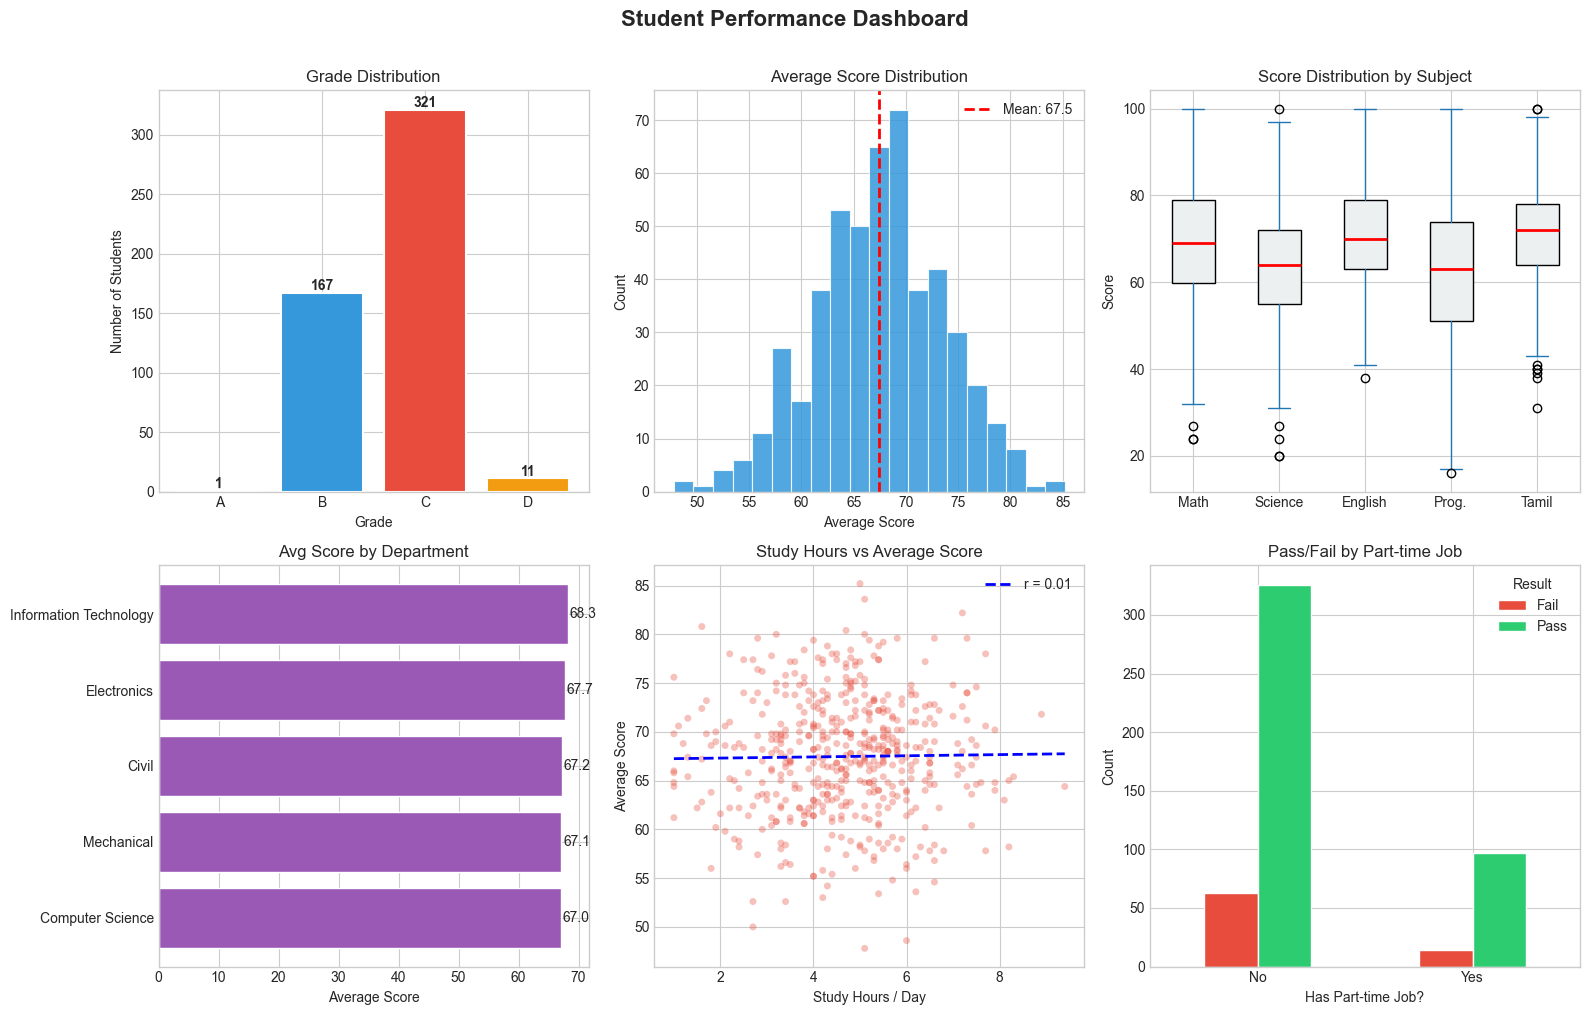

✅ Dashboard saved as student_performance_dashboard.png


In [14]:
# ── 6. Dashboard ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Student Performance Dashboard', fontsize=16, fontweight='bold', y=1.01)

colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

# Plot 1: Grade distribution
grade_counts = df['grade'].value_counts().sort_index()
axes[0,0].bar(grade_counts.index, grade_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Grade Distribution')
axes[0,0].set_xlabel('Grade')
axes[0,0].set_ylabel('Number of Students')
for i, (g, v) in enumerate(grade_counts.items()):
    axes[0,0].text(i, v+2, str(v), ha='center', fontweight='bold')

# Plot 2: Score distribution (histogram)
axes[0,1].hist(df['average_score'], bins=20, color='#3498db', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0,1].axvline(df['average_score'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {df["average_score"].mean():.1f}')
axes[0,1].set_title('Average Score Distribution')
axes[0,1].set_xlabel('Average Score')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Plot 3: Subject-wise box plot  ← FIXED
score_data = df[score_cols].rename(columns={
    'math_score'       : 'Math',
    'science_score'    : 'Science',
    'english_score'    : 'English',
    'programming_score': 'Prog.',
    'tamil_score'      : 'Tamil'
})
df_scores = df[score_cols].copy()
df_scores.columns = ['Math','Science','English','Prog.','Tamil']
df_scores.plot(kind='box', ax=axes[0,2], patch_artist=True,
               boxprops=dict(facecolor='#ecf0f1'), medianprops=dict(color='red', linewidth=2))
axes[0,2].set_title('Score Distribution by Subject')
axes[0,2].set_ylabel('Score')

# Plot 4: Department vs average score
dept_avg = df.groupby('department', observed=True)['average_score'].mean().sort_values()
axes[1,0].barh(dept_avg.index, dept_avg.values, color='#9b59b6', edgecolor='white')
axes[1,0].set_title('Avg Score by Department')
axes[1,0].set_xlabel('Average Score')
for i, v in enumerate(dept_avg.values):
    axes[1,0].text(v+0.3, i, f'{v:.1f}', va='center')

# Plot 5: Study hours vs Average score (scatter)
axes[1,1].scatter(df['study_hours_per_day'], df['average_score'],
                  alpha=0.35, s=25, c='#e74c3c', edgecolors='none')
z = np.polyfit(df['study_hours_per_day'], df['average_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['study_hours_per_day'].min(), df['study_hours_per_day'].max(), 100)
axes[1,1].plot(x_line, p(x_line), 'b--', linewidth=2, label=f'r = {corr:.2f}')
axes[1,1].set_title('Study Hours vs Average Score')
axes[1,1].set_xlabel('Study Hours / Day')
axes[1,1].set_ylabel('Average Score')
axes[1,1].legend()

# Plot 6: Pass / Fail by part-time job
pj_result = df.groupby(['part_time_job','result'], observed=True).size().unstack(fill_value=0)
pj_result.plot(kind='bar', ax=axes[1,2], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[1,2].set_title('Pass/Fail by Part-time Job')
axes[1,2].set_xlabel('Has Part-time Job?')
axes[1,2].set_ylabel('Count')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(title='Result')

plt.tight_layout()
plt.savefig('student_performance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as student_performance_dashboard.png')

---
## Step 7: Export Cleaned Dataset & Summary Report

In [ ]:
# ── Save cleaned CSV ─────────────────────────────────────────────────────────
df.to_csv('student_performance_cleaned.csv', index=False)
print('✅ Cleaned dataset saved: student_performance_cleaned.csv')
print(f'   Shape: {df.shape}')

# ── Generate text summary report ─────────────────────────────────────────────
report_lines = [
    '=' * 60,
    '       STUDENT PERFORMANCE ANALYSIS REPORT',
    '=' * 60,
    f'\nTotal Students Analyzed : {len(df)}',
    f'Pass Rate               : {(df["result"]=="Pass").mean()*100:.1f}%',
    f'Overall Average Score   : {df["average_score"].mean():.2f} / 100',
    f'Strongest Subject       : {df[score_cols].mean().idxmax().replace("_score","").title()}',
    f'Weakest Subject         : {df[score_cols].mean().idxmin().replace("_score","").title()}',
    '',
    '--- KEY INSIGHTS ---',
    f'1. {(df["result"]=="Pass").sum()} students passed ({(df["result"]=="Pass").mean()*100:.1f}%). Focus needed on the {(df["result"]=="Fail").sum()} who failed.', #observed=True- Finance    NaN   (no data but still shown)
    f'2. {df.groupby("department", observed=True)["average_score"].mean().idxmax()} dept has the highest avg score ({df.groupby("department", observed=True)["average_score"].mean().max():.1f}).',
    f'3. Students with part-time jobs score {df.groupby("part_time_job", observed=True)["average_score"].mean().diff().iloc[-1]:.1f} pts lower on average.',
    f'4. Study hours and score have a correlation of {corr:.2f} — more study hours = higher scores.',
    f'5. {(df["attendance_pct"] < 75).sum()} students ({(df["attendance_pct"]<75).mean()*100:.1f}%) are below the 75% attendance threshold.',
    '',
    '--- GRADE DISTRIBUTION ---',
] + [f'  Grade {g}: {(df["grade"]==g).sum()} students ({(df["grade"]==g).mean()*100:.1f}%)' for g in ['A','B','C','D','F']]

report_text = '\n'.join(report_lines)

with open('student_performance_report.txt', 'w') as f:
    f.write(report_text)

print('\n✅ Summary report saved: student_performance_report.txt')
print('\n' + report_text)

✅ Cleaned dataset saved: student_performance_cleaned.csv
   Shape: (500, 24)

✅ Summary report saved: student_performance_report.txt

       STUDENT PERFORMANCE ANALYSIS REPORT

Total Students Analyzed : 500
Pass Rate               : 84.6%
Overall Average Score   : 67.47 / 100
Strongest Subject       : Tamil
Weakest Subject         : Programming

--- KEY INSIGHTS ---
1. 423 students passed (84.6%). Focus needed on the 77 who failed.
2. Information Technology dept has the highest avg score (68.3).
3. Students with part-time jobs score 1.1 pts lower on average.
4. Study hours and score have a correlation of 0.01 — more study hours = higher scores.
5. 198 students (39.6%) are below the 75% attendance threshold.

--- GRADE DISTRIBUTION ---
  Grade A: 1 students (0.2%)
  Grade B: 167 students (33.4%)
  Grade C: 321 students (64.2%)
  Grade D: 11 students (2.2%)
  Grade F: 0 students (0.0%)
